All EDA in this notebook is performed on the **quality-filtered dataset only**.
Raw data is never visualized directly — doing so would include ghost markets,
stuck prices, and cancelled events that would distort every chart.

In [1]:
import sys
from pathlib import Path

_root = Path.cwd().resolve()
if not (_root / "src").is_dir():
    _root = _root.parent
sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess import load_filtered, prepare_features
from src.config import *

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

PALETTE = sns.color_palette("husl", 12)
Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

df = load_filtered("data/filtered/markets_filtered.csv")

Loaded filtered data from: C:\Yatharth\University\MachineLEARNING\hbrm\data\filtered\markets_filtered.csv
Shape: 2,385 rows × 144 columns

Column names:
    1. 'acceptingOrders'
    2. 'acceptingOrdersTimestamp'
    3. 'active'
    4. 'approved'
    5. 'archived'
    6. 'automaticallyActive'
    7. 'automaticallyResolved'
    8. 'bestAsk'
    9. 'bestBid'
   10. 'category'
   11. 'categoryMailchimpTag'
   12. 'clearBookOnStart'
   13. 'clobRewards'
   14. 'clobTokenIds'
   15. 'closed'
   16. 'closedTime'
   17. 'commentsEnabled'
   18. 'competitive'
   19. 'conditionId'
   20. 'createdAt'
   21. 'createdBy'
   22. 'creator'
   23. 'customLiveness'
   24. 'cyom'
   25. 'denominationToken'
   26. 'deploying'
   27. 'deployingTimestamp'
   28. 'description'
   29. 'disqusThread'
   30. 'enableOrderBook'
   31. 'endDate'
   32. 'endDateIso'
   33. 'eventStartTime'
   34. 'event_id'
   35. 'event_slug'
   36. 'event_title'
   37. 'featured'
   38. 'fee'
   39. 'feesEnabled'
   40. 'formatT

In [2]:
df_train, df_test, categories, cat_to_idx = prepare_features(
    df,
    {
        "epsilon": EPSILON,
        "min_category_size": MIN_CATEGORY_SIZE,
        "random_seed": RANDOM_SEED,
        "test_size": TEST_SIZE,
    },
)
df_model = pd.concat([df_train, df_test], axis=0, ignore_index=True)


--- Step 1: Clip market_prob ---
  Clipped to [0.0001, 0.9999].

--- Step 2: log_odds ---
  Added column log_odds = log(p / (1-p)).

--- Step 3: volume / liquidity / spread (median impute + z-score) ---
  volume_z: from 'volume' (median impute, z-score).
  liquidity_z: from 'liquidity' (median impute, z-score).
  spread_z: from 'spread' (median impute, z-score).

--- Step 4: category_str ---

--- Step 5: enforce min_category_size, then cat_idx (alphabetical) ---
  min_category_size=20: kept 2,385 / 2,385 rows.
  12 categories in modeling set; cat_idx 0..11.

--- Step 6: train/test split (stratified by cat_idx) ---

--- Step 7: Summary ---
  Total clean markets (train+test): 2,385

  Categories and counts:
      category_str  n_markets
           unknown       1249
            crypto        221
us-current-affairs        215
            sports        145
       coronavirus        120
       pop-culture        112
          business         95
              nfts         70
  ukraine & ru

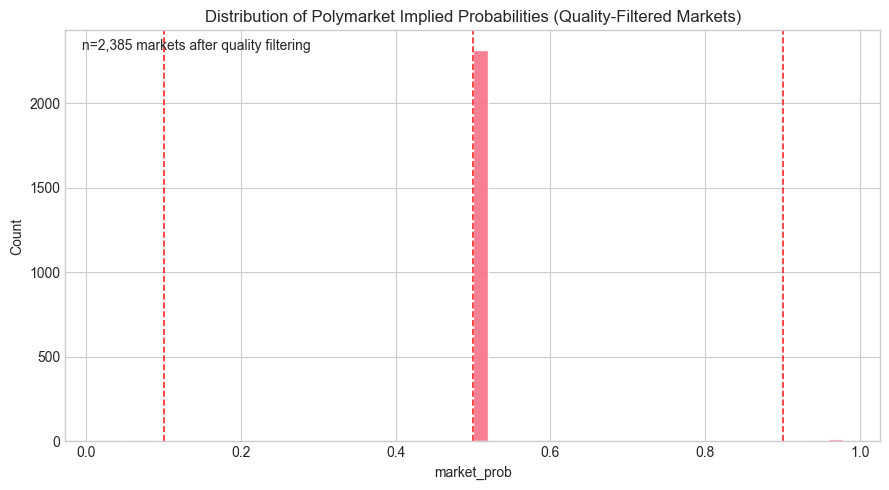

Saved: C:\Yatharth\University\MachineLEARNING\hbrm\outputs\figures\01_prob_distribution.png


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["market_prob"].astype(float), bins=50, color=PALETTE[0], edgecolor="white", alpha=0.9)
for x in (0.1, 0.5, 0.9):
    ax.axvline(x, color="red", linestyle="--", linewidth=1.2, alpha=0.85)
ax.set_title(
    "Distribution of Polymarket Implied Probabilities (Quality-Filtered Markets)",
    fontsize=12,
)
ax.set_xlabel("market_prob", fontsize=10)
ax.set_ylabel("Count", fontsize=10)
ax.text(
    0.02,
    0.98,
    f"n={len(df):,} markets after quality filtering",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
)
plt.tight_layout()
p_out = Path(FIGURES_DIR) / "01_prob_distribution.png"
plt.savefig(p_out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {p_out}")

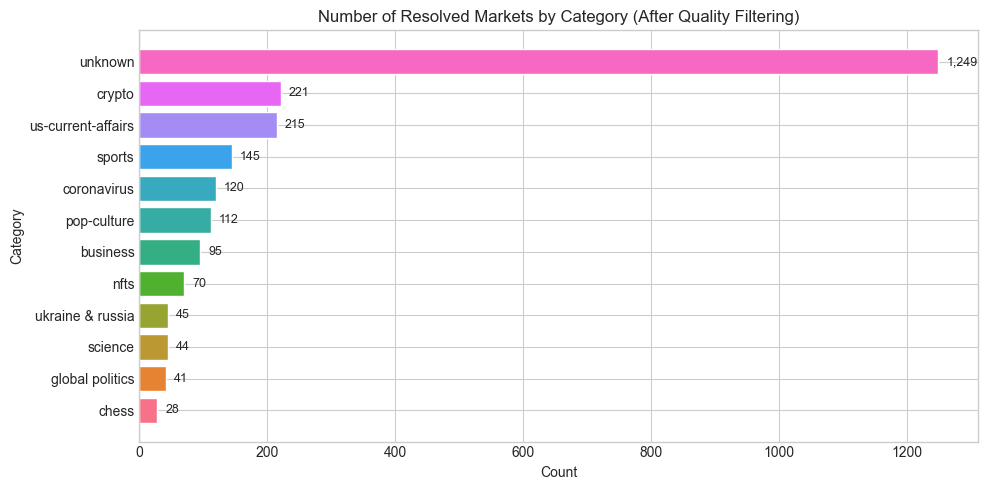

Saved: C:\Yatharth\University\MachineLEARNING\hbrm\outputs\figures\02_category_counts.png


In [4]:
cat_col = "category_clean" if "category_clean" in df.columns else "category"
vc = df[cat_col].fillna("unknown").astype(str).str.strip().str.lower().value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(vc))))
colors = sns.color_palette("husl", n_colors=len(vc))
bars = ax.barh(vc.index.astype(str), vc.values, color=colors, edgecolor="white")
ax.set_xlabel("Count", fontsize=10)
ax.set_ylabel("Category", fontsize=10)
ax.set_title("Number of Resolved Markets by Category (After Quality Filtering)", fontsize=12)
for b, val in zip(bars, vc.values):
    ax.text(b.get_width() + max(vc.values) * 0.01, b.get_y() + b.get_height() / 2, f"{val:,}", va="center", fontsize=9)
plt.tight_layout()
p_out = Path(FIGURES_DIR) / "02_category_counts.png"
plt.savefig(p_out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {p_out}")

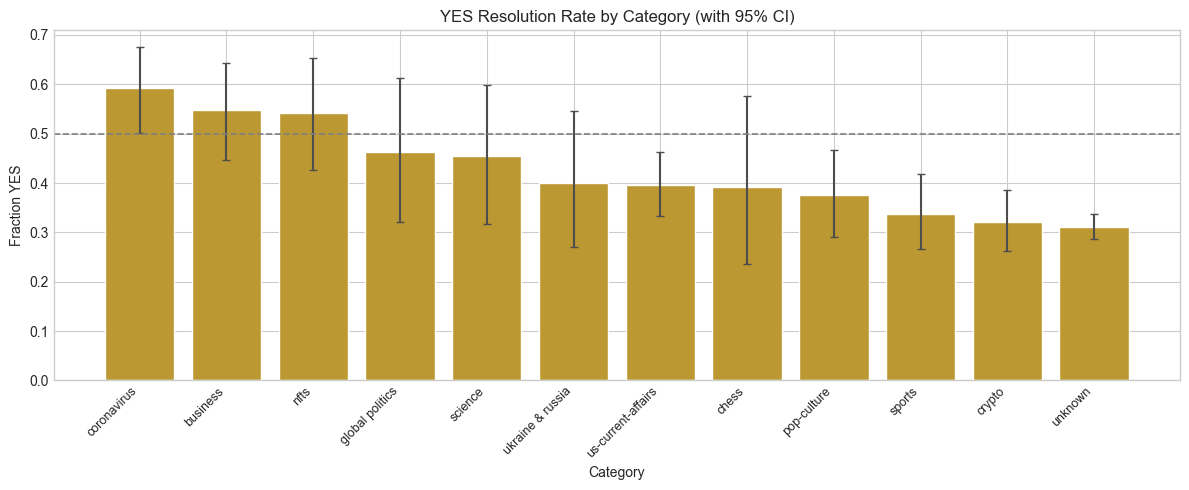

Saved: C:\Yatharth\University\MachineLEARNING\hbrm\outputs\figures\03_outcome_rate_by_category.png


In [5]:
def wilson_ci(k: np.ndarray, n: np.ndarray, z: float = 1.96) -> tuple[np.ndarray, np.ndarray]:
    k, n = np.asarray(k, dtype=float), np.asarray(n, dtype=float)
    p = np.divide(k, n, out=np.zeros_like(k), where=n > 0)
    denom = 1.0 + z**2 / np.maximum(n, 1.0)
    center = (p + z**2 / (2.0 * np.maximum(n, 1.0))) / denom
    half = z * np.sqrt(np.maximum(p * (1.0 - p) / np.maximum(n, 1.0) + z**2 / (4.0 * np.maximum(n, 1.0) ** 2), 0.0)) / denom
    return center - half, center + half


cat_col = "category_clean" if "category_clean" in df.columns else "category"
g = df.groupby(cat_col, observed=True).agg(n=("outcome", "size"), k=("outcome", "sum")).reset_index()
g["rate"] = g["k"] / g["n"]
lo, hi = wilson_ci(g["k"].values, g["n"].values)
g["lo"], g["hi"] = lo, hi
g = g.sort_values("rate", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(g))
ax.bar(x, g["rate"], color=PALETTE[2], edgecolor="white", yerr=[g["rate"] - g["lo"], g["hi"] - g["rate"]], capsize=3, ecolor="0.3")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.2)
ax.set_xticks(x)
ax.set_xticklabels(g[cat_col].astype(str), rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Fraction YES", fontsize=10)
ax.set_xlabel("Category", fontsize=10)
ax.set_title("YES Resolution Rate by Category (with 95% CI)", fontsize=12)
plt.tight_layout()
p_out = Path(FIGURES_DIR) / "03_outcome_rate_by_category.png"
plt.savefig(p_out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {p_out}")

C:\Users\yatha\AppData\Local\Temp\ipykernel_24904\2500289101.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="outcome", y="market_prob", ax=ax, palette="pastel")


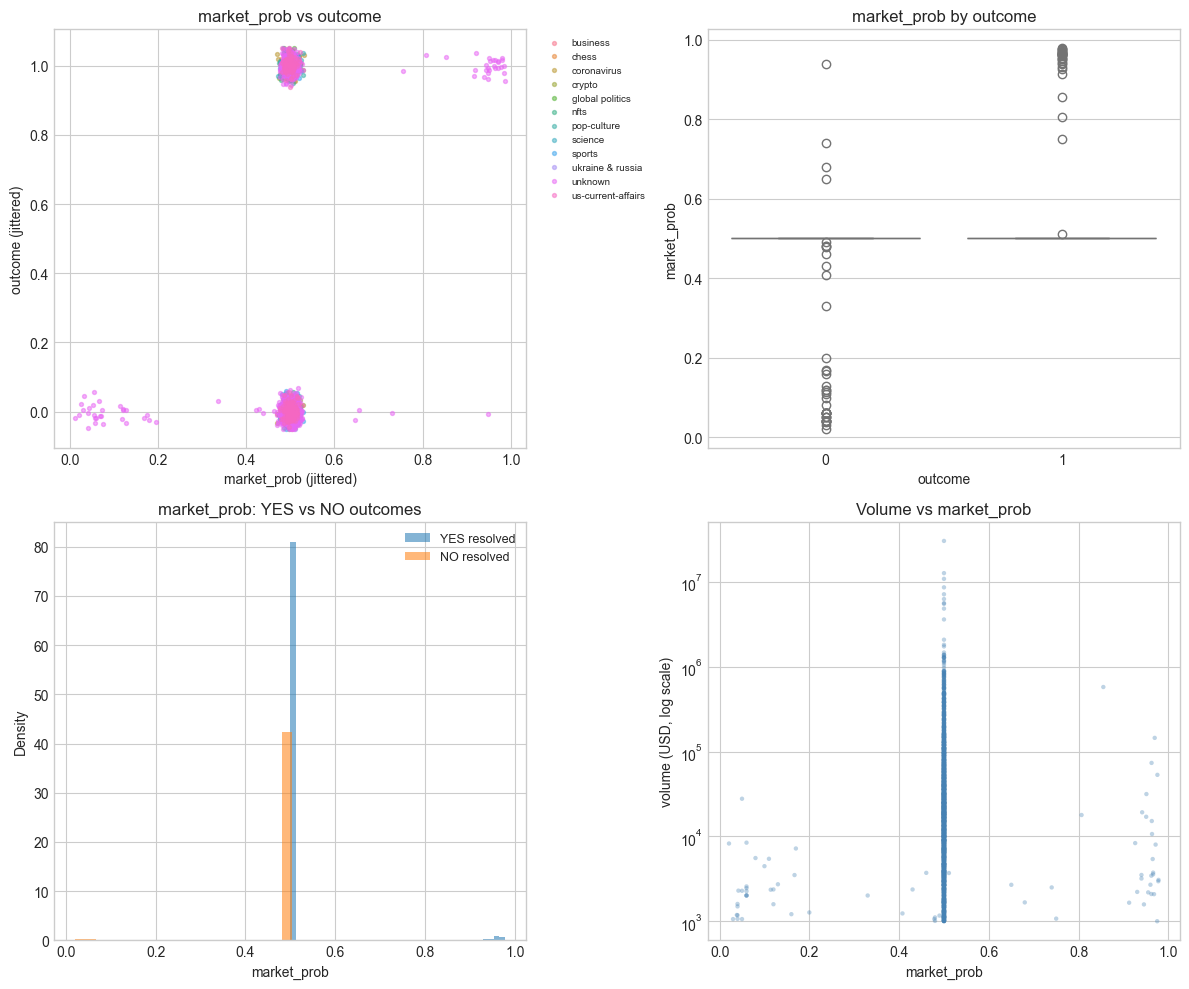

Saved: C:\Yatharth\University\MachineLEARNING\hbrm\outputs\figures\04_raw_calibration_check.png


In [6]:
rng = np.random.default_rng(RANDOM_SEED)
cat_col = "category_clean" if "category_clean" in df.columns else "category"
cats = df[cat_col].fillna("unknown").astype(str).str.strip().str.lower()
ucats = sorted(cats.unique())
cmap = dict(zip(ucats, sns.color_palette("husl", n_colors=max(len(ucats), 1))))
colors = cats.map(cmap)

mp = df["market_prob"].astype(float).values
oc = df["outcome"].astype(float).values
j_mp = mp + rng.normal(0, 0.01, size=len(mp))
j_oc = np.clip(oc + rng.normal(0, 0.02, size=len(oc)), -0.05, 1.05)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
for c in ucats:
    m = cats == c
    ax.scatter(j_mp[m], j_oc[m], s=8, alpha=0.5, label=c, color=cmap[c])
ax.set_xlabel("market_prob (jittered)", fontsize=10)
ax.set_ylabel("outcome (jittered)", fontsize=10)
ax.set_title("market_prob vs outcome", fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=1)

ax = axes[0, 1]
plot_df = pd.DataFrame({"market_prob": mp, "outcome": oc.astype(int)})
sns.boxplot(data=plot_df, x="outcome", y="market_prob", ax=ax, palette="pastel")
ax.set_xlabel("outcome", fontsize=10)
ax.set_ylabel("market_prob", fontsize=10)
ax.set_title("market_prob by outcome", fontsize=12)

ax = axes[1, 0]
yes = df["outcome"].astype(int) == 1
ax.hist(mp[yes], bins=40, alpha=0.55, label="YES resolved", color="tab:blue", density=True)
ax.hist(mp[~yes], bins=40, alpha=0.55, label="NO resolved", color="tab:orange", density=True)
ax.set_xlabel("market_prob", fontsize=10)
ax.set_ylabel("Density", fontsize=10)
ax.legend(fontsize=9)
ax.set_title("market_prob: YES vs NO outcomes", fontsize=12)

ax = axes[1, 1]
vol = pd.to_numeric(df["volume"], errors="coerce")
ax.scatter(mp, vol.replace(0, np.nan), s=10, alpha=0.35, c="steelblue", edgecolors="none")
ax.set_yscale("log")
ax.set_xlabel("market_prob", fontsize=10)
ax.set_ylabel("volume (USD, log scale)", fontsize=10)
ax.set_title("Volume vs market_prob", fontsize=12)

plt.tight_layout()
p_out = Path(FIGURES_DIR) / "04_raw_calibration_check.png"
plt.savefig(p_out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {p_out}")

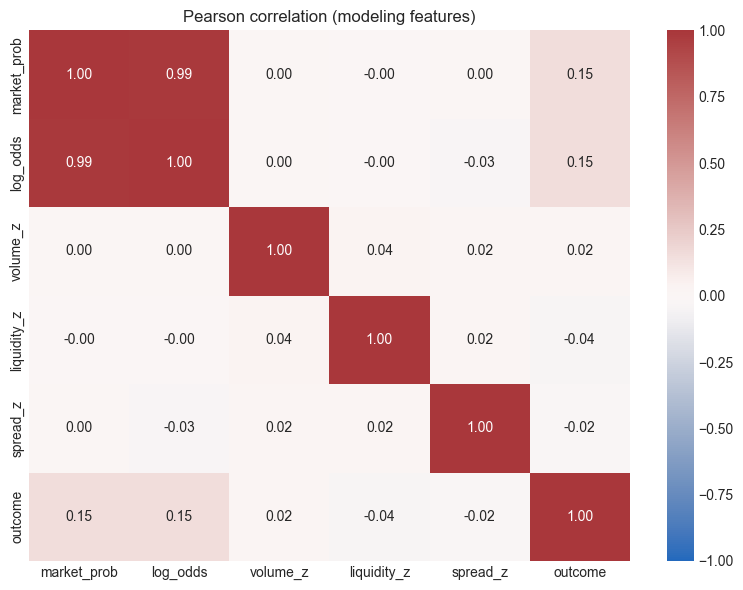

Saved: C:\Yatharth\University\MachineLEARNING\hbrm\outputs\figures\05_correlation_heatmap.png


In [7]:
cols = ["market_prob", "log_odds", "volume_z", "liquidity_z", "spread_z", "outcome"]
missing = [c for c in cols if c not in df_model.columns]
if missing:
    raise ValueError(f"Missing columns for heatmap: {missing}")
cm = df_model[cols].corr(method="pearson")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Pearson correlation (modeling features)", fontsize=12)
plt.tight_layout()
p_out = Path(FIGURES_DIR) / "05_correlation_heatmap.png"
plt.savefig(p_out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {p_out}")

In [ ]:
cat_col = "category_clean" if "category_clean" in df.columns else "category"
dnum = df.assign(
    market_prob=pd.to_numeric(df["market_prob"], errors="coerce"),
    volume=pd.to_numeric(df["volume"], errors="coerce"),
    liquidity=pd.to_numeric(df["liquidity"], errors="coerce"),
    spread=pd.to_numeric(df["spread"], errors="coerce"),
    outcome=df["outcome"].astype(float),
)
summ = (
    dnum.groupby(cat_col, observed=True)
    .agg(
        n_markets=("outcome", "count"),
        mean_prob=("market_prob", "mean"),
        std_prob=("market_prob", lambda x: float(x.std(ddof=0))),
        outcome_rate=("outcome", "mean"),
        mean_volume=("volume", "mean"),
        mean_liquidity=("liquidity", "mean"),
        mean_spread=("spread", "mean"),
    )
    .reset_index()
    .rename(columns={cat_col: "category"})
)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Summary statistics by category (filtered data)")
print(summ.to_string(index=False))

Summary statistics by category (filtered data)
          category  n_markets  mean_prob  std_prob  outcome_rate  mean_volume  mean_liquidity  mean_spread
          business         95     0.5000    0.0000        0.5474  41,411.6093        265.3376       1.0000
             chess         28     0.5000    0.0000        0.3929  19,742.3164        388.6279       1.0000
       coronavirus        120     0.5000    0.0000        0.5917 154,086.7634        458.5474       1.0000
            crypto        221     0.5000    0.0000        0.3213 135,833.4996        611.2452       1.0000
   global politics         41     0.5000    0.0000        0.4634  73,360.5493        365.5998       1.0000
              nfts         70     0.5000    0.0000        0.5429  23,427.9092        283.1904       1.0000
       pop-culture        112     0.5000    0.0000        0.3750  38,267.2048        303.6528       1.0000
           science         44     0.5000    0.0000        0.4545  29,875.5242        393.7866    